In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(
    "../outputs/cleaned_retail.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Quarter,Week,Day,DayName,Hour,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,4,49,1,Tuesday,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,4,49,1,Tuesday,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,4,49,1,Tuesday,7,False


In [6]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [7]:
rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "InvoiceNo": "nunique",

    "TotalSales": "sum"

})

In [8]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [9]:
rfm.shape

(5878, 3)

In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [11]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [12]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [13]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,12,77556.46,1
12347.0,2,8,4921.53,1
12348.0,75,5,2019.40,1
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,0


In [14]:
rfm["Cluster"].value_counts()

Cluster
1    3836
0    2003
2      35
3       4
Name: count, dtype: int64

In [15]:
cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,462.517224,2.213679,749.231879
1,66.758342,7.313608,2948.950233
2,25.942857,103.714286,81356.335200
3,3.500000,212.500000,428611.997500


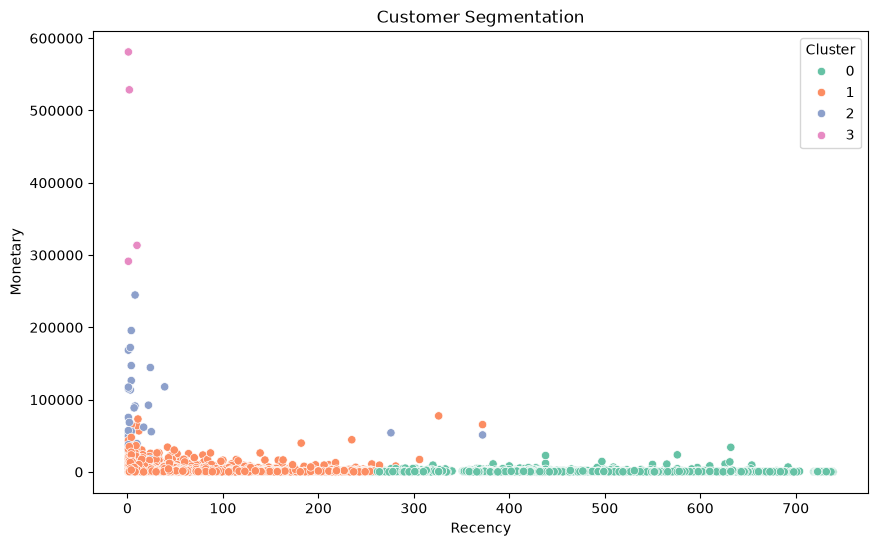

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=rfm,

    x="Recency",

    y="Monetary",

    hue="Cluster",

    palette="Set2"

)

plt.title("Customer Segmentation")

plt.show()

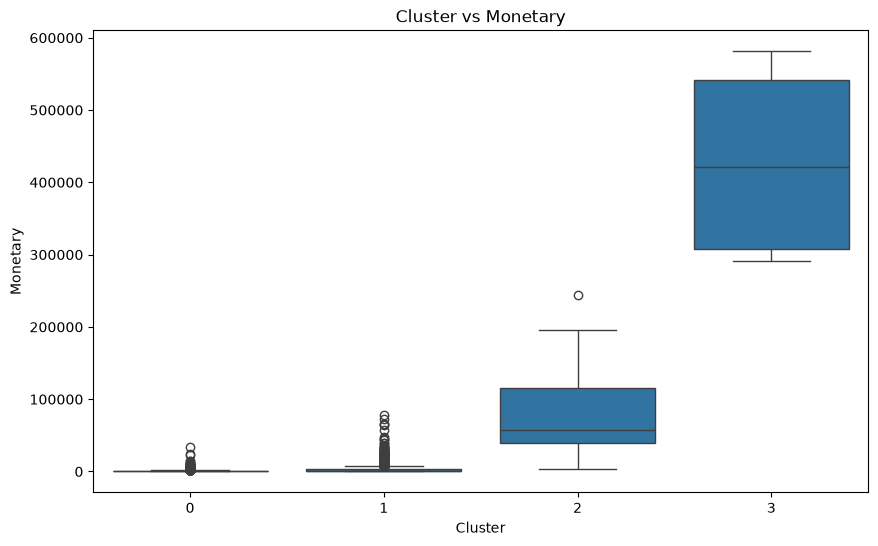

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(

    x="Cluster",

    y="Monetary",

    data=rfm

)

plt.title("Cluster vs Monetary")

plt.show()

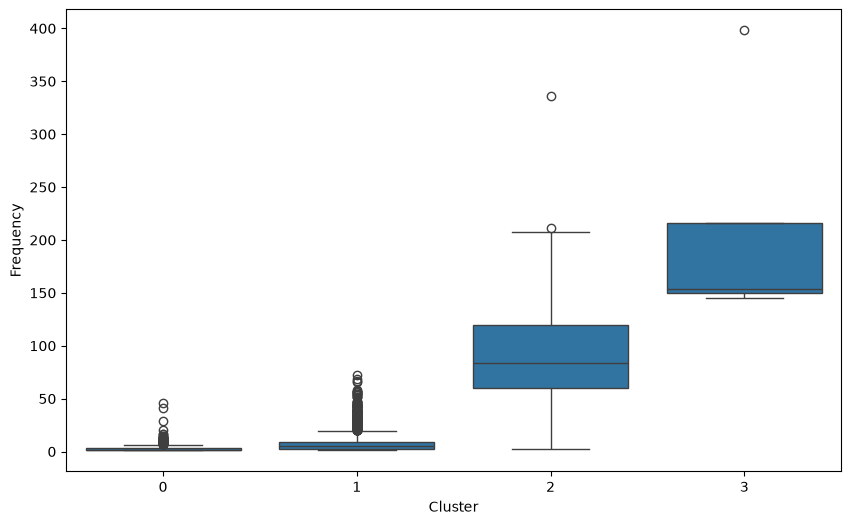

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(

    x="Cluster",

    y="Frequency",

    data=rfm

)

plt.show()

In [22]:
cluster_map = {

    0: "Lost",

    1: "Regular",

    2: "VIP",

    3: "Elite"

}

rfm["Segment"] = rfm["Cluster"].map(cluster_map)

In [23]:
rfm["Segment"].value_counts()

Segment
Regular    3836
Lost       2003
VIP          35
Elite         4
Name: count, dtype: int64

In [24]:
rfm.to_csv(

    "../outputs/customer_segments.csv",

    index=True

)

print("Customer Segmentation Completed")

Customer Segmentation Completed
